**Impact of Scaling in TensorFlow**

In [2]:
import tensorflow as tf
import numpy as np

# Synthetic data: house size vs price
X = np.array([[500], [1000], [2000], [4000]], dtype=np.float32)
y = np.array([150, 200, 300, 600], dtype=np.float32)

# ----------------------------
# Model without scaling
# ----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])
model.compile(optimizer="sgd", loss="mse")
history = model.fit(X, y, epochs=50, verbose=0)
print("Results:\n")
print("Weights (no scaling):", model.get_weights())

# ----------------------------
# Model with scaling
# ----------------------------
X_scaled = X / 4000.0  # Normalize input to [0,1]
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])
model2.compile(optimizer="sgd", loss="mse")
model2.fit(X_scaled, y, epochs=50, verbose=0)
print("Weights (scaled):", model2.get_weights())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Results:

Weights (no scaling): [array([[nan]], dtype=float32), array([nan], dtype=float32)]
Weights (scaled): [array([[131.74893]], dtype=float32), array([173.12646], dtype=float32)]


**Simple Imputation with Pandas (Mean and Median)**

In [3]:
import pandas as pd
import numpy as np

# Create a dataset with missing values
data = {'LotSize': [8000, 9200, np.nan, 7600, 8800, np.nan],
        'Bedrooms': [3, np.nan, 4, 2, np.nan, 3]}
df = pd.DataFrame(data)

# Fill missing values with mean and median
df_mean = df.fillna(df.mean(numeric_only=True))
df_median = df.fillna(df.median(numeric_only=True))

print("Original Data:\n", df)
print("\nMean Imputation:\n", df_mean)
print("\nMedian Imputation:\n", df_median)

Original Data:
    LotSize  Bedrooms
0   8000.0       3.0
1   9200.0       NaN
2      NaN       4.0
3   7600.0       2.0
4   8800.0       NaN
5      NaN       3.0

Mean Imputation:
    LotSize  Bedrooms
0   8000.0       3.0
1   9200.0       3.0
2   8400.0       4.0
3   7600.0       2.0
4   8800.0       3.0
5   8400.0       3.0

Median Imputation:
    LotSize  Bedrooms
0   8000.0       3.0
1   9200.0       3.0
2   8400.0       4.0
3   7600.0       2.0
4   8800.0       3.0
5   8400.0       3.0


**Scaling and Normalization Without Data Leakage**

Original X_train:
 [[  2]
 [  3]
 [  4]
 [100]]

StandardScaler X_train:
 [[-0.60107336]
 [-0.57726847]
 [-0.55346359]
 [ 1.73180541]]
StandardScaler X_test:
 [[-0.57726847]
 [ 0.54156114]]

MinMaxScaler X_train:
 [[0.        ]
 [0.01020408]
 [0.02040816]
 [1.        ]]
MinMaxScaler X_test:
 [[0.01020408]
 [0.48979592]]

RobustScaler X_train:
 [[-0.05940594]
 [-0.01980198]
 [ 0.01980198]
 [ 3.82178218]]
RobustScaler X_test:
 [[-0.01980198]
 [ 1.84158416]]


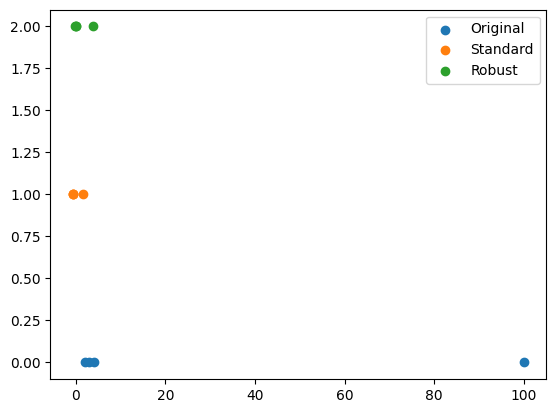

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import numpy as np
import matplotlib.pyplot as plt

# Example training and test data (Bedrooms as feature)
X_train = np.array([[2], [3], [4], [100]])  # Notice the outlier
X_test = np.array([[3], [50]])

# --- Standardization: (x - mean) / std ---
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)  # Fit only on train
X_test_std = scaler_std.transform(X_test)        # Apply same scaling

# --- Min-Max Normalization: scale to [0,1] ---
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)  # Fit only on train
X_test_mm = scaler_mm.transform(X_test)

# --- Robust Scaling: (x - median) / IQR ---
scaler_robust = RobustScaler()
X_train_rb = scaler_robust.fit_transform(X_train)  # Fit only on train
X_test_rb = scaler_robust.transform(X_test)

# --- Display results ---
print("Original X_train:\n", X_train)
print("\nStandardScaler X_train:\n", X_train_std)
print("StandardScaler X_test:\n", X_test_std)

print("\nMinMaxScaler X_train:\n", X_train_mm)
print("MinMaxScaler X_test:\n", X_test_mm)

print("\nRobustScaler X_train:\n", X_train_rb)
print("RobustScaler X_test:\n", X_test_rb)

plt.scatter(X_train, np.zeros_like(X_train), label="Original")
plt.scatter(X_train_std, np.ones_like(X_train_std), label="Standard")
plt.scatter(X_train_rb, np.ones_like(X_train_rb)*2, label="Robust")
plt.legend()
plt.show()

**Transformations in TensorFlow**

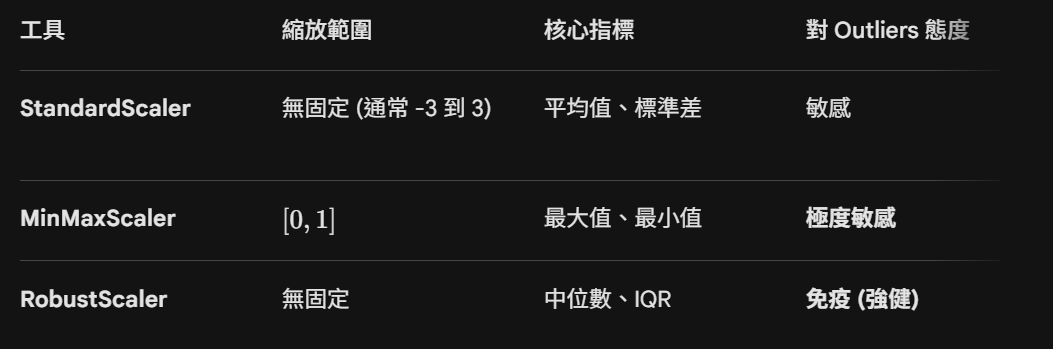

In [5]:
import tensorflow as tf
import numpy as np

# Original data: 3 samples, 2 features
X = np.array([
    [1.0, 10.0],
    [2.0, 20.0],
    [3.0, 30.0],
    [20000.0, 600000.0]
], dtype=np.float32)

# --- Log transform (log(1 + x)) ---
# Compresses large values, handles skewness
X_log = tf.math.log1p(X)

# --- Polynomial transform (x^2) ---
# Captures nonlinear relationships
X_poly = tf.math.pow(X, 2)

# --- Interaction term (feature1 * feature2) ---
# Create a new feature representing the interaction of two features
X_inter = tf.expand_dims(X[:, 0] * X[:, 1], axis=1)

# --- Print results ---
print("Original X:\n", X)
print("\nLog Transform:\n", X_log.numpy())
print("\nPolynomial Transform:\n", X_poly.numpy())
print("\nInteraction Term:\n", X_inter.numpy())

Original X:
 [[1.e+00 1.e+01]
 [2.e+00 2.e+01]
 [3.e+00 3.e+01]
 [2.e+04 6.e+05]]

Log Transform:
 [[ 0.6931472  2.3978953]
 [ 1.0986123  3.0445223]
 [ 1.3862944  3.4339871]
 [ 9.903538  13.304687 ]]

Polynomial Transform:
 [[1.0e+00 1.0e+02]
 [4.0e+00 4.0e+02]
 [9.0e+00 9.0e+02]
 [4.0e+08 3.6e+11]]

Interaction Term:
 [[1.0e+01]
 [4.0e+01]
 [9.0e+01]
 [1.2e+10]]


**Detecting Outliers in TensorFlow**

In [6]:
import numpy as np

# Synthetic data with an outlier
X = np.array([10, 12, 11, 13, 12, 500], dtype=np.float32)

# --- Step 1: Compute IQR ---
Q1 = np.percentile(X, 25)  # 25th percentile
Q3 = np.percentile(X, 75)  # 75th percentile
IQR = Q3 - Q1               # Interquartile range

# --- Step 2: Define outlier bounds using 1.5*IQR rule ---
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# --- Step 3: Filter out outliers ---
mask = (X >= lower) & (X <= upper)
X_filtered = X[mask]

# --- Step 4: Winsorization / clipping ---
X_clipped = np.clip(X, lower, upper)

# --- Step 5: Display results ---
print("Original Data:   ", X)
print("Filtered Data:   ", X_filtered)  # Outlier 500 removed
print("Clipped Data:    ", X_clipped)   # Outlier replaced with upper bound

Original Data:    [ 10.  12.  11.  13.  12. 500.]
Filtered Data:    [10. 12. 11. 13. 12.]
Clipped Data:     [10. 12. 11. 13. 12. 15.]
